# Simualation of a NewAthena WFI survey field demonstrating how to add necessary backgrounds
3rd Aug 2026 - J. Aird (University of Edinburgh)

Here we demonstrate how to run a WFI simulation of a generic survey field, using mock catalogues produced by Stefano Marchesi (see http://cxb.oas.inaf.it/mock.html). Specifically, download the following files:
- [g07_a100deg2_sixte.tar.gz](http://cxb.oas.inaf.it/g07_a100deg2_sixte.tar.gz)
- [clusters_a1deg2_sixte.tar.gz](http://cxb.oas.inaf.it/clusters_a1deg2_sixte.tar.gz)
- [galaxies_a1deg2_sixte.tar.gz](http://cxb.oas.inaf.it/galaxies_a1deg2_sixte.tar.gz)

to run this notebook and untar in the SIXTE-tutorial directory. Don't forget to unpack the spectra in each folder as well.

We focus in particular on the inclusion of approapriate background components, including:
1) the soft Galactic (Milky Way) foreground for a typical high Galactic latitude sky postion that is *focused* by the telescope (i.e. in the field-of-view, it remains a diffuse component); and 
2) the straylight that consists of both soft Galactic foreground and extragalactic (cosmic) X-ray background that is *not* focused but introduced from straylight from areas of sky outside the field-of-view.

The soft Galactic foreground is included as a SIMPUT file (generated within this notebook), whereas straylight requires a dedicated background file that is available from here: https://www.sternwarte.uni-erlangen.de/sixte/instruments/ (scroll to Supplemantary files and download [straylight_NewAthena.tar.gz](https://www.sternwarte.uni-erlangen.de/~sixte/downloads/sixte/supplementary/straylight_NewAthena.tar.gz) - place in your SIXTE directory under $SIXTE/share/sixte/ and untar there). 

We note that the straylight here assumes a generic (high Galactic latitude) pointing and also blurs the contribution of the individual point sources that make up the CXB. It is thus suitable for a generic survey field, but observations close to individual brioght sources will be affected by a stronger straylight pattern on the detector that is not accounted for here. Such structured straylight *may* be possible to avoid with suitable choice of pointing/roll angle. In contrast, this overall stray background from the diffuse Galactic foreground and CXB will *always* be present (and the Galactic emission will be stronger if observing close to the Galactic plane). 

In addition to the above backgrounds, other background components in WFI observations are:

3) the particle (detector) background - included by default in a SIXTE run.
4) remaining unresolved/undetected extragalactic sources (primarily AGN) that form part of the CXB. This contribution is accounted for via the input mock catalogues that go far below the NewAthena sensitivity limits. This contribution depends on exposure time. If not using the 
mocks it can be added as an additional "diffuse" component, assuming a certain resolved fraction, in a similar manner to the soft Galactic foreground (see the [WFI background files](https://www.mpe.mpg.de/ATHENA-WFI/public/resources/background/WFI-MPE-ANA-10-013_i9.6_Preparation_of_Background_Files.pdf) and adapt the Xspec model below accordingly).

In all cases we assume WFI observations are carried out **with** the optical blocking filter (as now recommended by the WFI Team).

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
import tempfile
from funcs import run_comm,showximage
import matplotlib.pyplot as plt
from astropy.io import fits

from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
tmpDir = tempfile.mkdtemp()
os.environ["PFILES"] = tmpDir + ":" + os.environ["PFILES"]
os.environ["HEADASNOQUERY"] = ""
os.environ["HEADASPROMPT"] = "/dev/null/"
SIXTE = os.environ["SIXTE"]
SIMPUT = os.environ["SIMPUT"]
xmldir = f"{SIXTE}/share/sixte/instruments/athena-wfi/wfi_w_filter" # N.B. default recommendation from WFI team is now to assume *with* the filter.
bkgfile= f"{SIXTE}/share/sixte/foreground_release/combined_linescan_foreground_qe_w_filter_cluster_removed.fits" 
# N.B. w/ filter. "cluster removed" indicates a birght cluster in the inputs used to generate the stray estimate is removed. 
# The straylight is technically for a line scan observation but as events re recorded in detector co-ordinates it provides a reasonable average for a single (dithered) pointing as simulated here.

prefix='wfisim/' # prefix for output simulation files (/ stores to a directory)
os.makedirs(prefix, exist_ok=True)

xml=f'{xmldir}/ld_wfi_ff_all_chips.xml'

exptime=200 # in ks

### Creating a SIMPUT file to capture the soft Galactic foreground

We adopt the model described here: https://www.mpe.mpg.de/ATHENA-WFI/public/resources/background/WFI-MPE-ANA-10-013_i9.6_Preparation_of_Background_Files.pdf
(but without the component needed for unresolved AGN)

Simulate for a 50x50 arcmin region centred on RA=0.0, Dec=0.0

srcFLux is the total 0.1-15 keV flux in this region (as the model is defined per sq arcmin need to multiply the flux in xspec x 50 x 50)

In [69]:
comm = f'{SIXTE}/bin/simputfile Simput=Galactic_foreground.simput Src_ID=1 Src_Name=GalForeground ' \
        'RA=0.0 Dec=0.0 XSPECFILE=Galactic_foreground.xcm ' \
        'Emin=0.1 Emax=15 Nbins=5000 logEgrid=yes ' \
        'srcFlux=1.592025e-11 ' \
        'clobber=yes ' \
        'ImageFile=50x50arcmin_flat_img.fits '
run_comm(comm)




/Users/ja457/software/sixte/bin/simputfile Simput=Galactic_foreground.simput Src_ID=1 Src_Name=GalForeground RA=0.0 Dec=0.0 XSPECFILE=Galactic_foreground.xcm Emin=0.1 Emax=15 Nbins=5000 logEgrid=yes srcFlux=1.592025e-11 clobber=yes ImageFile=50x50arcmin_flat_img.fits 
finished successfully!


		XSPEC version: 12.15.1
	Build Date/Time: Thu Jul  9 21:56:13 2026


!XSPEC12>statistic chi
Default fit statistic is set to: Chi-Squared
   This will apply to all current and newly loaded spectra.

!XSPEC12>method leven 10 0.01

!XSPEC12>abund angr
 Solar Abundance Vector set to angr:  Anders E. & Grevesse N. Geochimica et Cosmochimica Acta 53, 197 (1989)

!XSPEC12>xsect bcmc
 Cross Section Table set to bcmc:  Balucinska-Church and McCammon, 1998

!XSPEC12>cosmo 70 0 0.73

!XSPEC12>xset delta 0.01
Parameter delta values for fits will now be 0.01 * parValue

!XSPEC12>systematic 0

 The default systematic error for models is set to 0


!XSPEC12>model  apec + phabs*apec  ;            0.099       0.

### Reducing the G07 mock 100 sq deg catalogue to a more manageable ~1 sq deg

In [ ]:
g07fits = fits.open('g07_a100deg2_sixte/g07_a100deg2_sixte.fits')
g07dat=g07fits[1].data
sel = (g07dat['RA']>-0.5) & (g07dat['RA']<0.5) & (g07dat['DEC']>-0.5) & (g07dat['DEC']<0.5)
g07fits[1].data = g07dat[sel]
g07fits.writeto('g07_a100deg2_sixte/g07_a1deg2_sixte.fits') # note saved to same directory as 100deg2 sim to access same spec files

### generate attitude for lissajous dither

In [91]:
comm='attgen_dither '\
     f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
     'Amplitude=0.035 '\
     'SrcRA=0.0 '\
     'SrcDec=0.0 '\
     f'Exposure={exptime*1000:.0f} '\
     'clobber=yes'
run_comm(comm)


attgen_dither Attitude=attitude_lissajous_200ks.fits Amplitude=0.035 SrcRA=0.0 SrcDec=0.0 Exposure=200000 clobber=yes


## Now run sixtesim
This takes a while.

In [95]:
comm= f'{SIXTE}/bin/sixtesim '\
      f'XMLFile={xml} '\
      f'RA=0.0 Dec=0.0 '\
      f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
      f'Prefix={prefix} '\
      f'Simput=Galactic_foreground.simput,clusters_a1deg2_sixte/clusters_a1deg2_sixte.fits,galaxies_a1deg2_sixte/galaxies_a1deg2_sixte.fits,g07_a100deg2_sixte/g07_a1deg2_sixte.fits '\
      f'EvtFile=evt.fits '\
      f'Exposure={exptime*1000} clobber=yes chatter=1 '\
      f'BkgEventFile={bkgfile}'
run_comm(comm)


/Users/ja457/software/sixte/bin/sixtesim XMLFile=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter/ld_wfi_ff_all_chips.xml RA=0.0 Dec=0.0 Attitude=attitude_lissajous_200ks.fits Prefix=wfisim/ Simput=Galactic_foreground.simput,clusters_a1deg2_sixte/clusters_a1deg2_sixte.fits,galaxies_a1deg2_sixte/galaxies_a1deg2_sixte.fits,g07_a100deg2_sixte/g07_a1deg2_sixte.fits EvtFile=evt.fits Exposure=200000 clobber=yes chatter=1 BkgEventFile=/Users/ja457/software/sixte/share/sixte/foreground_release/combined_linescan_foreground_qe_w_filter_cluster_removed.fits
Seed = 1407670066

*** Warning in convSimputMIdpSpecWithARF: the spectrum 'Galactic_foreground.simput[SPECTRUM,1]' does not cover the full energy range of the ARF! ***

*** Warning in convSimputMIdpSpecWithARF: the spectrum 'clusters_a1deg2_sixte/spectra_clusters/cluster_spectrum_kT_1.6_z_0.6.fits[SPECTRUM]' does not cover the full energy range of the ARF! ***

*** Warning in convSimputMIdpSpecWithARF: the spectrum 

### Merge chips files with ftmerge

In [96]:
comm= f'ftmerge '\
      f'{prefix}/chip0_evt.fits,{prefix}/chip1_evt.fits,{prefix}/chip2_evt.fits,{prefix}/chip3_evt.fits '\
      f'{prefix}/combined_evt.fits clobber=yes'
run_comm(comm)


ftmerge wfisim//chip0_evt.fits,wfisim//chip1_evt.fits,wfisim//chip2_evt.fits,wfisim//chip3_evt.fits wfisim//combined_evt.fits clobber=yes


### Make an image of all events

In [14]:
comm= f'{SIXTE}/bin/imgev '\
      f'EvtFile={prefix}/combined_evt.fits  '\
      f'Image={prefix}/full_img.fits  '\
      f'CoordinateSystem=0 Projection=TAN '\
      f'NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg '\
      f'CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 '\
      f'CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true '\
      f'clobber=yes'
run_comm(comm)




/Users/ja457/software/sixte/bin/imgev EvtFile=wfisim//combined_evt.fits  Image=wfisim//full_img.fits  CoordinateSystem=0 Projection=TAN NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true clobber=yes
initialize ...
open event file 'wfisim//combined_evt.fits' ...
finished successfully!



(<Figure size 1400x800 with 2 Axes>, <WCSAxes: >)

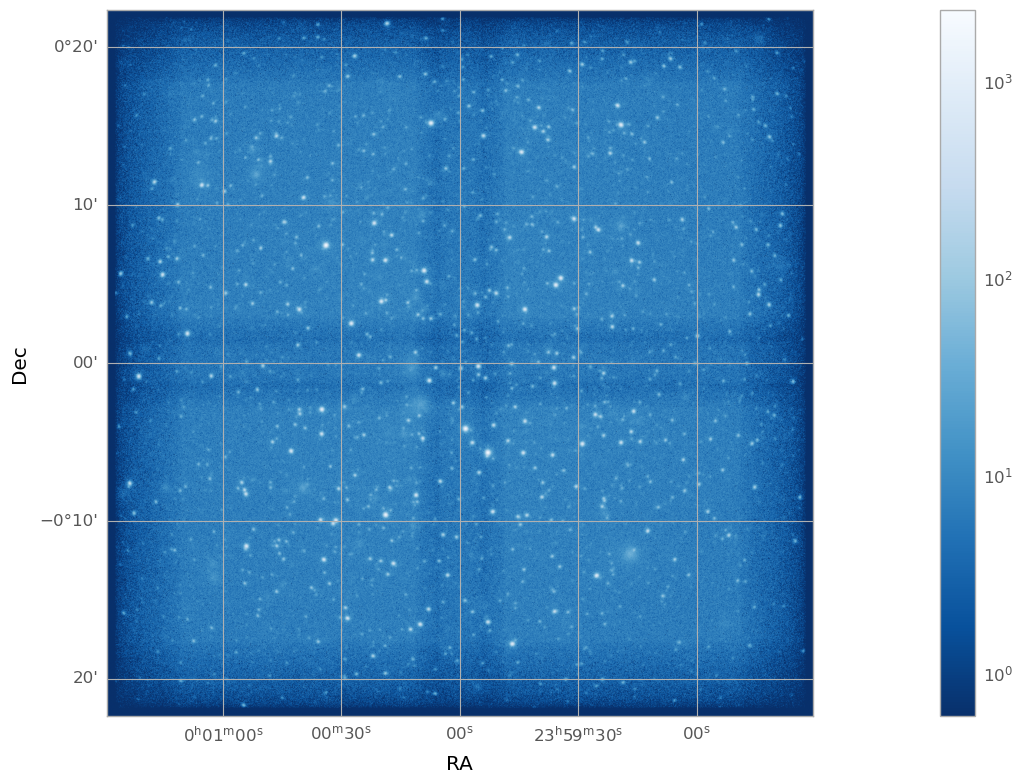

In [25]:
showximage(prefix+'full_img.fits')

### Extract events in 0.7-2keV range only (this is roughly the traditional "soft" band, but setting a lower limit of 0.7 keV reduces the impact of soft Galactic background a little)

In [9]:
comm= f'ftcopy "{prefix}/combined_evt.fits[EVENTS][SIGNAL > 0.7 && SIGNAL<2.0]" {prefix}/nsoft_evt.fits clobber=yes'
run_comm(comm)


ftcopy "wfisim//combined_evt.fits[EVENTS][SIGNAL > 0.7 && SIGNAL<2.0]" wfisim//nsoft_evt.fits clobber=yes


### Make an image of the nsoft band

In [ ]:
comm= f'{SIXTE}/bin/imgev '\
      f'EvtFile={prefix}/nsoft_evt.fits  '\
      f'Image={prefix}/nsoft_img.fits  '\
      f'CoordinateSystem=0 Projection=TAN '\
      f'NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg '\
      f'CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 '\
      f'CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true '\
      f'clobber=yes'
run_comm(comm)




imgev EvtFile=wfisim//nsoft_evt.fits  Image=wfisim//nsoft_img.fits  CoordinateSystem=0 Projection=TAN NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 CDELT1=-6.207043e-04 CDELT2=6.207043e-04 history=true clobber=yes
initialize ...
open event file 'wfisim//nsoft_evt.fits' ...
finished successfully!



(<Figure size 1400x800 with 2 Axes>, <WCSAxes: >)

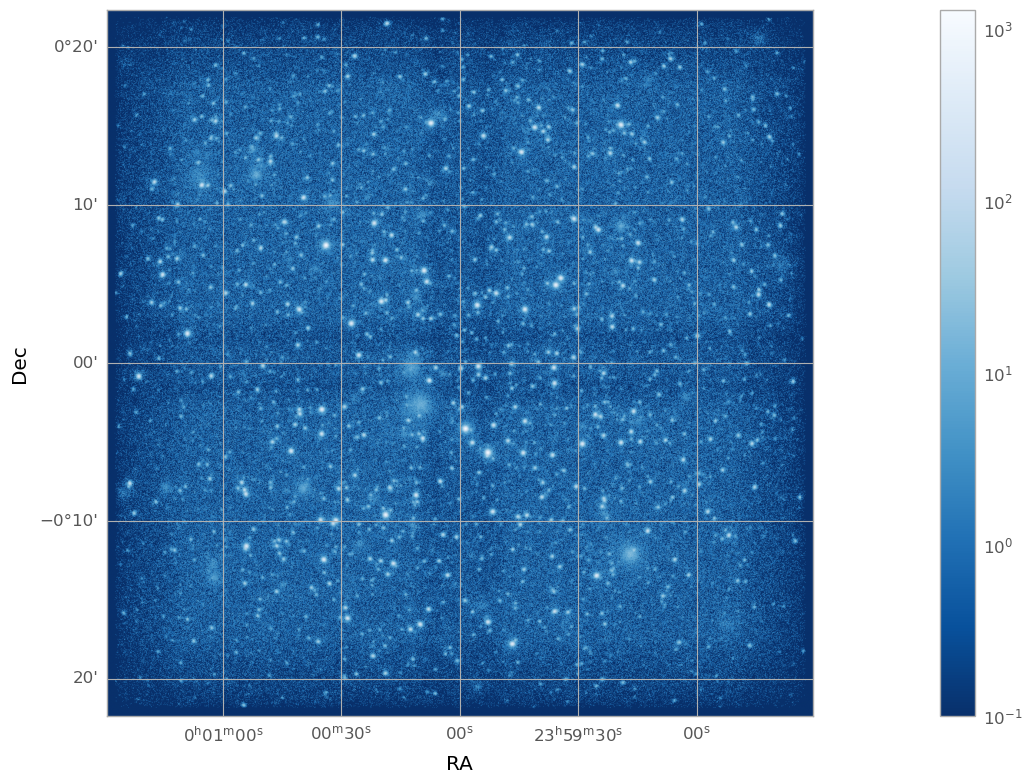

In [24]:
showximage(prefix+'nsoft_img.fits')

### Make an exposure map at a representative energy of 1.0 keV

In [18]:
comm= f'{SIXTE}/bin/exposure_map '\
      f'Vignetting={xmldir}/athena_sixte_vig_13rows_20260511.fits '\
      f'RA=0.0 Dec=0.0 '\
      f'Attitude=attitude_lissajous_{exptime:.0f}ks.fits '\
      f'Exposuremap={prefix}expo_map_dithered_{exptime:.0f}ks.fits '\
      f'XMLFile={xml} '\
      f'fov_diameter=120 '\
      f'CoordinateSystem=0 projection_type=TAN '\
      f'vig_en=1.0 '\
      f'NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg '\
      f'CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 '\
      f'CDELT1=-6.207043e-04 CDELT2=6.207043e-04 '\
      f'TSTART=0 timespan={exptime*1000} dt=100 '\
      f'chatter=3 clobber=true '
run_comm(comm)



/Users/ja457/software/sixte/bin/exposure_map Vignetting=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter/athena_sixte_vig_13rows_20260511.fits RA=0.0 Dec=0.0 Attitude=attitude_lissajous_200ks.fits Exposuremap=wfisim/expo_map_dithered_200ks.fits XMLFile=/Users/ja457/software/sixte/share/sixte/instruments/athena-wfi/wfi_w_filter/ld_wfi_ff_all_chips.xml fov_diameter=120 CoordinateSystem=0 projection_type=TAN vig_en=1.0 NAXIS1=1201 NAXIS2=1201 CUNIT1=deg CUNIT2=deg CRVAL1=0.0 CRVAL2=0.0 CRPIX1=601 CRPIX2=601 CDELT1=-6.207043e-04 CDELT2=6.207043e-04 TSTART=0 timespan=200000 dt=100 chatter=3 clobber=true 
### Warning: Geometry keyword not set in XML, will be set to default (rectangular array)!
### Warning: Geometry keyword not set in XML, will be set to default (rectangular array)!
### Warning: Geometry keyword not set in XML, will be set to default (rectangular array)!
### Warning: Geometry keyword not set in XML, will be set to default (rectangular array)!
calcu

(<Figure size 1400x800 with 2 Axes>, <WCSAxes: >)

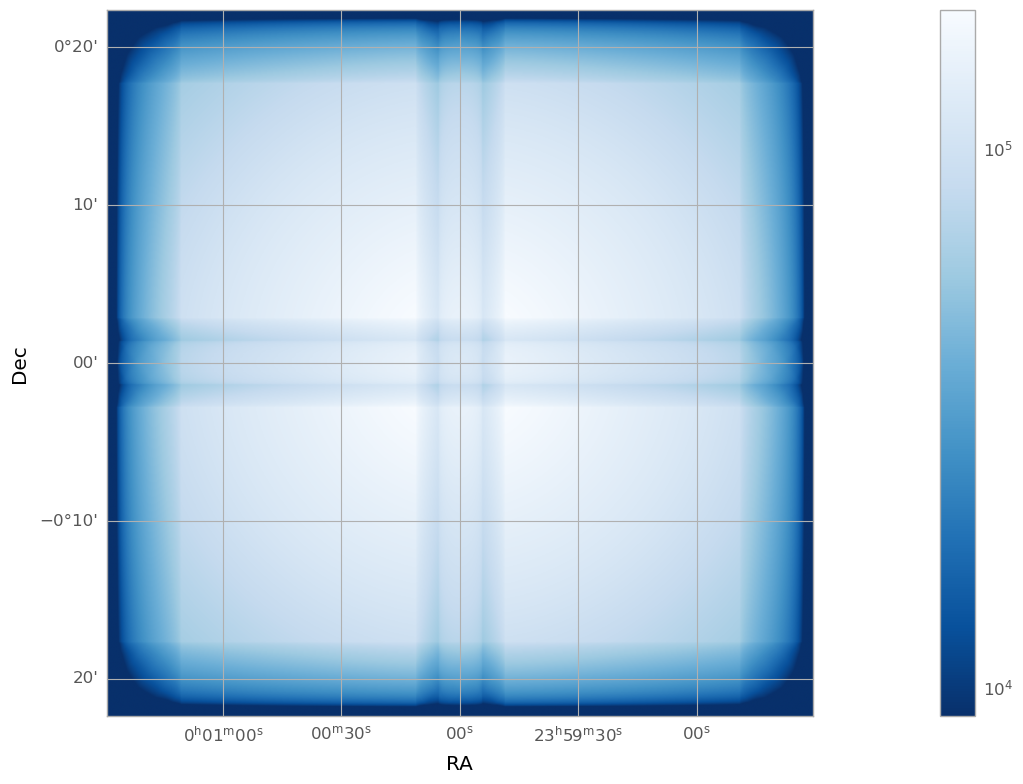

In [23]:
showximage(prefix+f'expo_map_dithered_{exptime:.0f}ks.fits')